# Day 05：史诗对决 —— Plain Net vs ResNet> 🌉 第七周 · ResNet 的奇迹 · 第 5 天前四天，我们从认识退化问题，到理解残差连接的直觉，再到手写残差块——每一步都是铺垫。今天，是验收成果的时刻。我们要进行一场**史诗级的对决**：> **Plain Net vs ResNet**：同样的深度，同样的数据，同样的训练条件——唯一的区别就是那一条"近道"。**今天的任务**：1. 在多种深度下系统性对比 Plain Net 和 ResNet2. 可视化决策边界，直观感受两者的差异3. 绘制"退化曲线 vs 残差曲线"，见证 ResNet 如何逆转乾坤---

## 1. 历史剧场：ImageNet 2015 的碾压级胜利2015 年的 ImageNet 竞赛中，何恺明的 ResNet 以碾压级优势夺冠：| 模型 | 层数 | Top-5 错误率 | 排名 ||---|---|---|---|| VGGNet | 19 | 7.32% | 2nd || GoogLeNet | 22 | 6.67% | 1st (2014) || **ResNet** | **152** | **3.57%** | **1st (2015)** |3.57% 的错误率，**首次超越了人类的水平**（约 5.1%）。而更令人震惊的是：ResNet-152 的层数是 VGGNet-19 的 8 倍，但训练反而更容易。如果没有残差连接，152 层的网络根本无法训练。今天，我们要用代码复现这种"碾压"。---

## 2. 生活隐喻：有安全绳 vs 没安全绳的攀岩- **Plain Net**：没有安全绳的攀岩。每一步都必须踩稳，一旦某一步失误，就可能一路滑到底- **ResNet**：有安全绳的攀岩。即使某一步踩空了，安全绳（跳跃连接）会把你拉回上一个安全点安全绳不会帮你往上爬（学习还是要靠梯度下降），但它保证了你**不会往下掉**（深层至少不差于浅层）。---

<p align="center">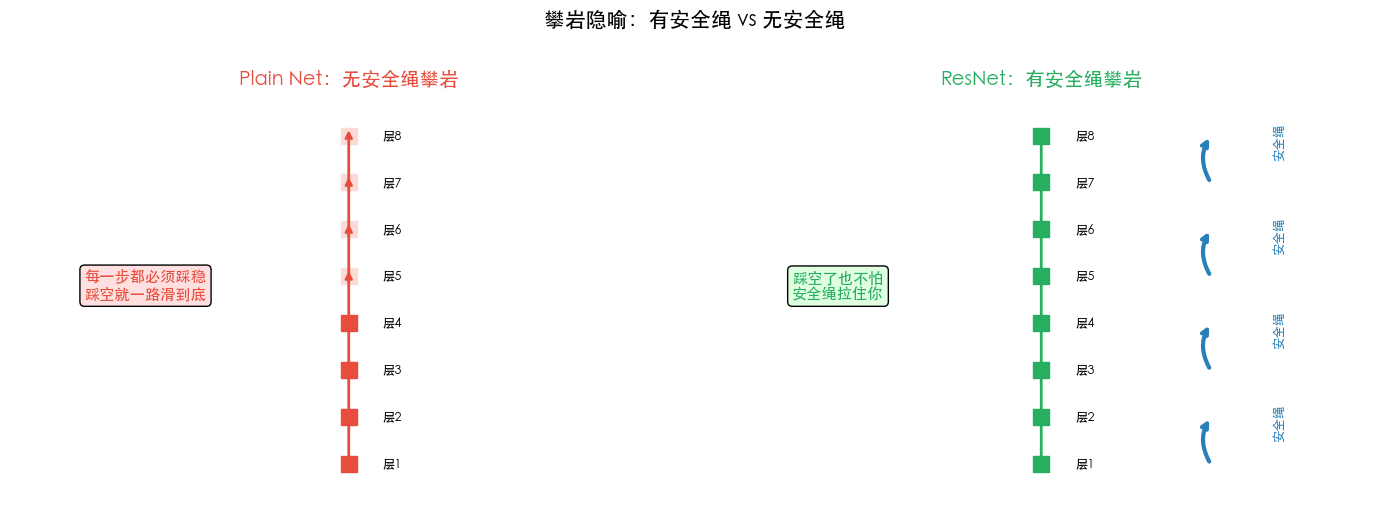</p>*安全绳攀岩隐喻示意图*

## 3. 代码实验室：全面对决### 3.1 准备工作

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.2 数据集：双月牙（Moons）这次我们用一个经典的数据集——双月牙，它比同心圆更难一点。

In [ ]:
def make_moons_data(n_samples=500, noise=0.15):    np.random.seed(42)    n = n_samples // 2    theta_moon1 = np.linspace(0, np.pi, n)    theta_moon2 = np.linspace(0, np.pi, n)    x_moon1 = np.column_stack([        np.cos(theta_moon1),        np.sin(theta_moon1)    ]) + np.random.randn(n, 2) * noise    x_moon2 = np.column_stack([        1 - np.cos(theta_moon2),        0.5 - np.sin(theta_moon2)    ]) + np.random.randn(n, 2) * noise    X = np.vstack([x_moon1, x_moon2]).astype(np.float32)    y = np.concatenate([np.zeros(n), np.ones(n)]).astype(np.float32)    return torch.tensor(X), torch.tensor(y).unsqueeze(1)X_moons, y_moons = make_moons_data()fig, ax = plt.subplots(1, 1, figsize=(6, 6))for label, color, marker in [(0, '#e74c3c', 'x'), (1, '#2ecc71', 'o')]:    mask = y_moons.squeeze() == label    ax.scatter(X_moons[mask, 0], X_moons[mask, 1],               c=color, marker=marker, s=25, alpha=0.6, label=f'类别 {int(label)}')ax.set_title('双月牙数据集', fontsize=14)ax.legend(fontsize=12)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 3.3 定义两种网络

In [ ]:
class PlainBlock(nn.Module):    def __init__(self, hidden_size):        super().__init__()        self.layer1 = nn.Linear(hidden_size, hidden_size)        self.bn1 = nn.BatchNorm1d(hidden_size)        self.layer2 = nn.Linear(hidden_size, hidden_size)        self.bn2 = nn.BatchNorm1d(hidden_size)    def forward(self, x):        out = F.relu(self.bn1(self.layer1(x)))        out = self.bn2(self.layer2(out))        out = F.relu(out)        return outclass ResidualBlock(nn.Module):    def __init__(self, hidden_size):        super().__init__()        self.layer1 = nn.Linear(hidden_size, hidden_size)        self.bn1 = nn.BatchNorm1d(hidden_size)        self.layer2 = nn.Linear(hidden_size, hidden_size)        self.bn2 = nn.BatchNorm1d(hidden_size)    def forward(self, x):        identity = x        out = F.relu(self.bn1(self.layer1(x)))        out = self.bn2(self.layer2(out))        out = out + identity        out = F.relu(out)        return outclass BattleNet(nn.Module):    def __init__(self, block_type='plain', num_blocks=8, hidden_size=64):        super().__init__()        self.input_layer = nn.Linear(2, hidden_size)        self.input_relu = nn.ReLU()        BlockClass = ResidualBlock if block_type == 'residual' else PlainBlock        self.blocks = nn.Sequential(*[BlockClass(hidden_size) for _ in range(num_blocks)])        self.output_layer = nn.Linear(hidden_size, 1)        self.sigmoid = nn.Sigmoid()    def forward(self, x):        x = self.input_relu(self.input_layer(x))        x = self.blocks(x)        x = self.sigmoid(self.output_layer(x))        return x

### 3.4 系统性对决：从 2 层到 32 层

In [ ]:
depth_list = [2, 4, 8, 12, 16, 20, 24, 32]epochs = 300results = {'plain': {}, 'residual': {}}for num_blocks in depth_list:    print(f"深度 {num_blocks} 层...")    torch.manual_seed(42)    plain_net = BattleNet(block_type='plain', num_blocks=num_blocks)    opt_p = torch.optim.Adam(plain_net.parameters(), lr=0.01)    loss_fn = nn.BCELoss()    for epoch in range(epochs):        pred = plain_net(X_moons)        loss = loss_fn(pred, y_moons)        opt_p.zero_grad()        loss.backward()        opt_p.step()    plain_acc = ((plain_net(X_moons) > 0.5).float() == y_moons).float().mean().item()    results['plain'][num_blocks] = plain_acc    torch.manual_seed(42)    res_net = BattleNet(block_type='residual', num_blocks=num_blocks)    opt_r = torch.optim.Adam(res_net.parameters(), lr=0.01)    for epoch in range(epochs):        pred = res_net(X_moons)        loss = loss_fn(pred, y_moons)        opt_r.zero_grad()        loss.backward()        opt_r.step()    res_acc = ((res_net(X_moons) > 0.5).float() == y_moons).float().mean().item()    results['residual'][num_blocks] = res_acc    print(f"  Plain: {plain_acc:.2%}  |  ResNet: {res_acc:.2%}")print("\n对决完成！")

### 3.5 退化曲线 vs 残差曲线

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))plain_accs = [results['plain'][d] for d in depth_list]res_accs = [results['residual'][d] for d in depth_list]ax.plot(depth_list, plain_accs, 'o-', color='#e74c3c', linewidth=2.5,        markersize=8, label='Plain Net (无近道)')ax.plot(depth_list, res_accs, 's-', color='#2ecc71', linewidth=2.5,        markersize=8, label='ResNet (有近道)')ax.fill_between(depth_list, plain_accs, res_accs,                where=[r > p for r, p in zip(res_accs, plain_accs)],                alpha=0.15, color='#2ecc71', label='ResNet 优势区域')ax.set_xlabel('网络深度 (Block 数)', fontsize=14)ax.set_ylabel('训练准确率', fontsize=14)ax.set_title('史诗对决：退化曲线 vs 残差曲线', fontsize=16)ax.legend(fontsize=12, loc='lower left')ax.grid(True, alpha=0.3)ax.set_ylim(0.4, 1.0)plt.tight_layout()plt.show()

### 解读- **Plain Net**（红色）：随着深度增加，准确率逐渐下降——退化曲线- **ResNet**（绿色）：深度增加，准确率保持稳定甚至提升——残差曲线- **绿色阴影区域**：ResNet 相对于 Plain Net 的优势，深度越大优势越明显---

## 4. 决策边界可视化让我们看看两种网络学到的决策边界有什么不同。

In [ ]:
def plot_decision_boundary(model, X, y, title, ax):    h = 0.02    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)    Z = model(grid).detach().numpy().reshape(xx.shape)    ax.contourf(xx, yy, Z, alpha=0.3, levels=np.linspace(0, 1, 20), cmap='RdYlGn')    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)    for label, color, marker in [(0, '#e74c3c', 'x'), (1, '#2ecc71', 'o')]:        mask = y.squeeze() == label        ax.scatter(X[mask, 0], X[mask, 1], c=color, marker=marker, s=20, alpha=0.6)    acc = ((model(X) > 0.5).float() == y).float().mean().item()    ax.set_title(f'{title}\nAcc: {acc:.2%}', fontsize=13)    ax.set_aspect('equal')depth = 20torch.manual_seed(42)plain_20 = BattleNet(block_type='plain', num_blocks=depth)opt = torch.optim.Adam(plain_20.parameters(), lr=0.01)for _ in range(300):    pred = plain_20(X_moons)    loss = nn.BCELoss()(pred, y_moons)    opt.zero_grad()    loss.backward()    opt.step()torch.manual_seed(42)res_20 = BattleNet(block_type='residual', num_blocks=depth)opt = torch.optim.Adam(res_20.parameters(), lr=0.01)for _ in range(300):    pred = res_20(X_moons)    loss = nn.BCELoss()(pred, y_moons)    opt.zero_grad()    loss.backward()    opt.step()fig, axes = plt.subplots(1, 2, figsize=(14, 6))plot_decision_boundary(plain_20, X_moons, y_moons, f'Plain Net ({depth} Blocks)', axes[0])plot_decision_boundary(res_20, X_moons, y_moons, f'ResNet ({depth} Blocks)', axes[1])plt.tight_layout()plt.show()

### 解读- **Plain Net**：决策边界混乱，无法正确拟合月牙形状- **ResNet**：决策边界清晰，完美地贴合了月牙的形状同样的深度，同样的数据，同样的训练条件——唯一的区别就是那条"近道"。---

## 5. 终极对比表

In [ ]:
print("=" * 60)print("终极对比：Plain Net vs ResNet")print("=" * 60)print(f"{'深度':>6s} | {'Plain Net':>12s} | {'ResNet':>12s} | {'ResNet优势':>12s}")print("-" * 60)for d in depth_list:    p = results['plain'][d]    r = results['residual'][d]    diff = r - p    symbol = "↑" if diff > 0 else "↓"    print(f"{d:>6d} | {p:>11.2%} | {r:>11.2%} | {diff:>+10.2%} {symbol}")print("-" * 60)print()print("结论：深度越大，ResNet 的优势越明显。")print("这不仅仅是一个技巧——它改变了深度学习的格局。")

---

## 今日结语今天我们进行了一场史诗级的对决，用数据和图表铁证如山地展示了 ResNet 的威力：1. **退化曲线**：Plain Net 随深度增加而退化2. **残差曲线**：ResNet 随深度增加保持稳定甚至提升3. **决策边界**：ResNet 学到更清晰、更准确的边界4. **核心原因**：残差连接让信息有了"近道"，深层至少不差于浅层何恺明用一行代码 `out = F(x) + x`，解决了困扰深度学习界多年的退化问题。这告诉我们：**最伟大的创新，往往来自最简单的想法。**下周，我们将深入理解残差连接背后的梯度流原理，以及如何从单个残差块构建完整的 ResNet 架构。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 有安全绳的攀岩 vs 没安全绳的攀岩 | ResNet vs Plain Net || 安全绳保证不会往下掉 | 跳跃连接保证深层不差于浅层 || 退化曲线：越深越差 | Plain Net 的退化问题 || 残差曲线：越深越稳 | ResNet 的稳定训练 || 决策边界混乱 | 模型欠拟合/训练不充分 || 决策边界清晰 | 模型学到了正确的特征 || 深度越大优势越明显 | ResNet 的优势随深度增加而增长 || 一行代码改变世界 | out = F(x) + x |